In [3]:
import yfinance as yf

ticker = "AAPL"
df = yf.download(ticker, start="2014-01-01", end="2024-01-01")
df.to_csv("AAPL_2014_224.csv")

Failed to get ticker 'AAPL' reason: Failed to perform, curl: (28) Connection timed out after 30002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: Timeout('Failed to perform, curl: (28) Connection timed out after 30002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

In [5]:
df = pd.read_csv("AAPL_2014_2024.csv", index_col=0, parse_dates=True)
df["Return"] = df["Close"].pct_change()
df["Vol_5"] = df["Return"].rolling(5).std()
df["Vol_10"] = df["Return"].rolling(10).std()
df["Vol_20"] = df["Return"].rolling(20).std()
df["TargetVol"] = df["Vol_5"].shift(-1)
df = df.dropna()

In [6]:
X = df[["Return", "Vol_5", "Vol_10", "Vol_20"]]
y = df["TargetVol"]

In [7]:
#time-series split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

test_df = df.iloc[split:]

In [8]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 6, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [9]:
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_absolute_error')


In [10]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 6, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [11]:
best_params = grid_search.best_params_

model = RandomForestRegressor(
    **best_params,
    random_state=42
)

In [12]:
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 0.0028328555873653326


Naive MAE: 0.004248636700285598
Rolling Mean MAE: 0.004659063586269145


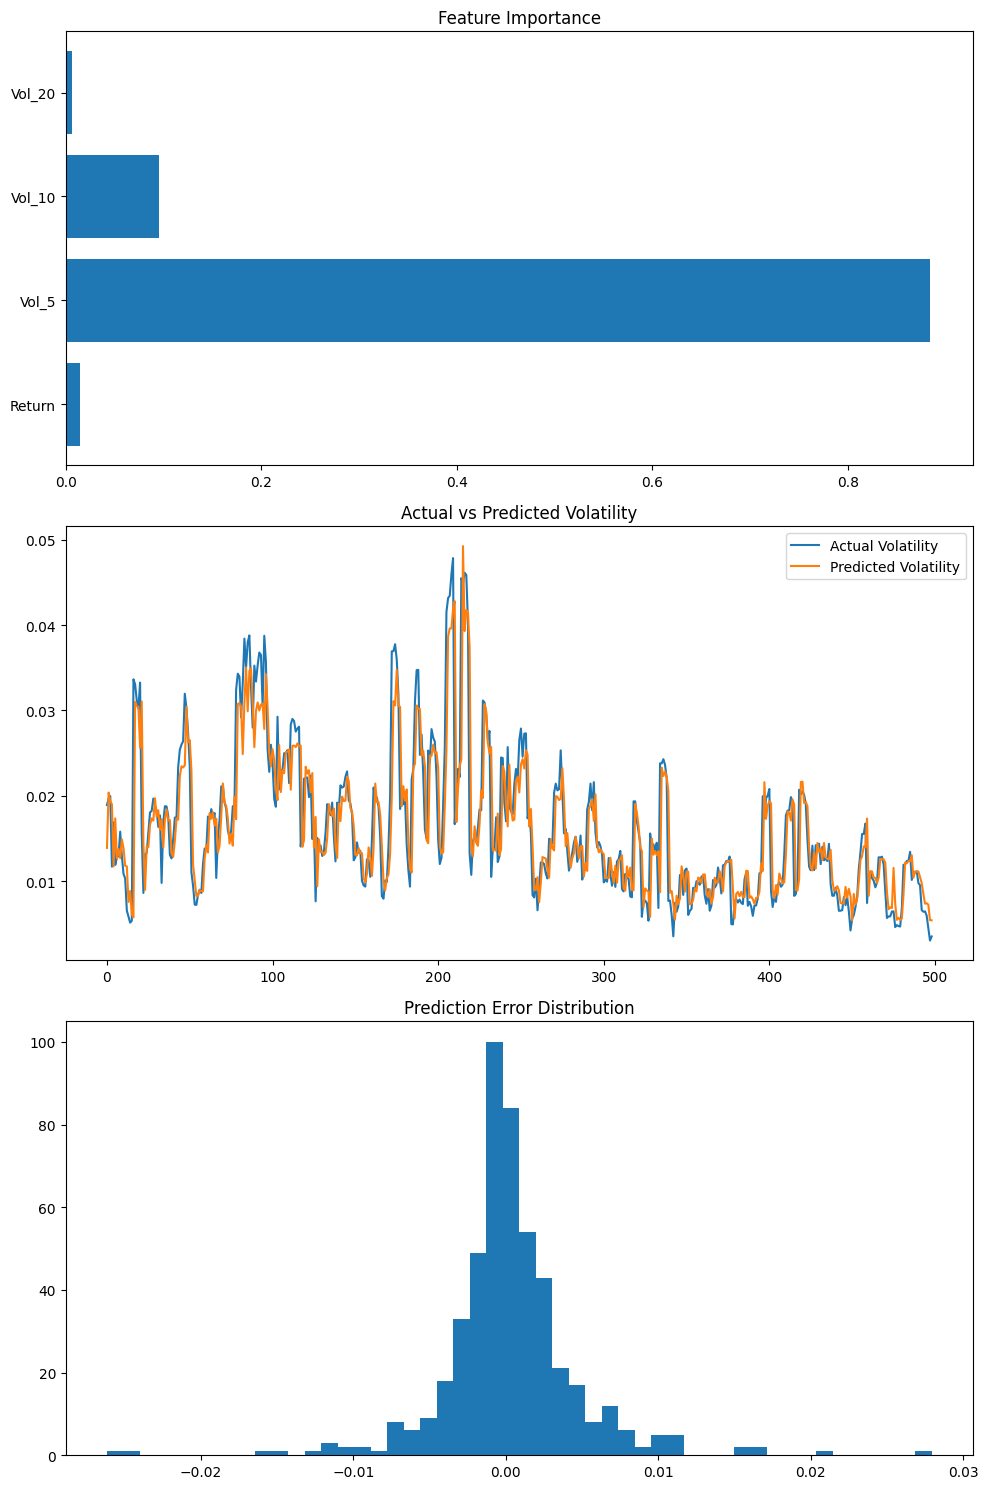

In [16]:
# Baseline comparison
naive_pred = test_df["Vol_5"].shift(1)
naive_mae = mean_absolute_error(test_df["TargetVol"][1:], naive_pred[1:])
print("Naive MAE:", naive_mae)

rolling_pred = test_df["Vol_5"].rolling(5).mean()
roll_mae = mean_absolute_error(test_df["TargetVol"][4:], rolling_pred[4:])
print("Rolling Mean MAE:", roll_mae)

fig, axs = plt.subplots(3, 1, figsize=(10, 15))

#Feature Importance
importances = model.feature_importances_
features = X_train.columns
axs[0].barh(features, importances)
axs[0].set_title("Feature Importance")

# Actual vs Predicted Volatility
axs[1].plot(test_df["TargetVol"].values, label="Actual Volatility")
axs[1].plot(preds, label="Predicted Volatility")
axs[1].legend()
axs[1].set_title("Actual vs Predicted Volatility")

# Prediction Error Distribution
errors = test_df["TargetVol"].values - preds
axs[2].hist(errors, bins=50)
axs[2].set_title("Prediction Error Distribution")

plt.tight_layout()
plt.show()